In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs

# Prerequisites

- Technical
  - **Python programing**
  - **Numpy skills**
- Theoretical
  - **Linear Algebra**: Understanding of matrix operations such as multiplication, transpositions, inverse...
  - **Descriptive Statistics**: mean, expected value, variance, bias, distributions (especially Gaussian(normal)/Bernoulli as they're the most common)...
  - **Probabilites**: Conditionnal probabilities, Bayes' theorem

# Naive bayes

# Introduction

## 1. What is Naive Bayes classification ?
Naive Bayes classification is method based on a probabilistic approach, based on the **Bayes Theorem**. The goal here is to include **prior knowledge** when studiying an event.
Different to the classic approach called **frequentist**:
- Classic: we estimate $P[x]$
- Bayesian: we estimate $P[x|w]$, where w serves as a hypothesis, it can be an event to which we have such and such knowledge.

In the case of bayesian classification, we can interpret our classification of event $x$ as: `In the world i live in, knowing that i'm in a situation w, i estimate the probability of event x as` $P[x|w]$.

Which is different from the frequentist approach where we take the occurence of event $x$ as granted.

## 2. What problem does Naive Bayes classification solve?

It solves supervised learning problems by predicting class labels for data points based on probability, assuming independence between features.

## 3. Real-World applications

- **High-dimensional text classification**: classifiying documents, identifying topics, determining the sentiment in a text ...
- **Spam filtering**: classifying messages as 'spam'/'not spam' by calculating the likelihood of words occuring in either category.
- **Multi-Class Classification**: It efficiently handles tasks involving more than two classes, such as classifying news articles into multiple topics.
- etc...

## 4. When vs when not to use

|Feature| **Use Naive Bayes when** | **Avoid Naive Bayes when** |
| :--- | :--- | :--- |
|Dataset Size	|You have a small or medium dataset; it performs well with less training data.	|You have a massive dataset and the resources for more complex models like Gradient Boosting.|
|Feature Correlation|	Features are independent or have very weak correlations (e.g., word counts in a document).|	Features are highly correlated (e.g., height and weight), as the "Naive" assumption will be violated.|
|Speed Requirements|	You need real-time or near-instant predictions; it is extremely fast and low-resource.|	Maximum predictive accuracy is the only priority, regardless of training or inference time.|
|Input Type|	You are dealing with high-dimensional data like Natural Language Processing (NLP).|	You are working with complex image data or intricate numerical patterns.|
|Model Interpretability|	You need a "White Box" model where you can easily explain how a specific probability was reached.|	You need to capture complex, non-linear relationships between features.|

# Naive Bayes Classifier

## 1. Mathematical formulation

### Conditional Probability

$$P[A∩B] = P[A|B].P[B] = P[B|A]P[A]$$

### Naive Bayes Theorem

let A,B, and C be three events, we have:

$$P[A|B,C] = \frac{P[B|A,C]P[A|C]}{P[B|C]}$$

- $P[A|B,C]$: posterior probability of A given B and C.
- $P[B|A,C]$: the likelihood of event B given A and C.
- $P[A|C]$: the probability with prior of A given C.
- $P[A|C]$: the probability with prior of B given C.


### Estimation
Given $P[x|y,X]$: the likelihood of observing the class x if it belongs to class $y$ and $X$ being the dataset.

- The **Naive Bayes Hypothesis(NBH)**:
  - $x$ is a conjuction of attribute values.
  - We assume that the attributes are independent random variables (no correlation between them).
  - if we have informations about the correlation between these attributes we can use them.

- If we apply NBH, assuming that $x$ is described by $P$ attributes noted $a_j$ with values $v_j$ respectively, we have:

$$P[x|y,X] ≈ P[a_1=v_1|y,X]×…×P[a_P=v_P|y,X] = \prod_{i=1}^{i=P}P[a_i=v_i|y,X]$$

Each term $P[a_1=v_1|y,X]$ is estimated using the dataset $X$. Its estimation depends on the qualitative or quantitative nature of the attribute.

### <u>MAP (Maximal A Posteriori) Class</u>

Having calculated $P[x|y,X], \forall{y} \in Y$, we can predict its class as the one that **maximizes** the posterior probability:
$$y_{MAP} = argmax_{y \in Y}P[x|y, X] = argmax_{y \in Y}P[x|y,X]P[y|X]$$

### <u>ML (Maximal Likelihood) Class</u>

If we don't have $P[y,X]$ and $P[x|y]$, we get the Maximal Likelihood class:
$$y_{ML} = argmax_{y \in Y}P[x|y, X]$$

If the examples are uniformely split across all the classes $Y$. We have $P[y|X]=\frac{1}{|Y|}$, the ML and MAP classes are the same.

## 3. Intuitive Example

Say we have two classes: $c1$ = male, $c2$ = female
We have a person whose sex we don't know, his name is "Morgan" or m.
Classifying Morgan as male or female is equivalent to asking is it more probable that Morgan is male or female, in other words which is greater $P[male|Morgan]$ or $P[female|Morgan]$, using the Naive bayes classification we can calculate these probabilities:
$$P[male|m] = \frac{P[m|male]P[male]}{p[m]}$$

where:
  - $P[m|male]$: is the probability of being called Morgan given you are a male.
  - $P[male]$: the probability of being male.
  - $P[m]$: the probability of being named Morgan.

Say we have this dataset:

|**name**|**sex**|
| :--- | :--- |
|Morgan| Male|
|Claudia| Female|
|Morgan| Female|
|Morgan| Female|
|Alberto| Male|
|Karin| Female|
|Nina| Female|
|Sergio| Male|

we can use it to apply Bayes classification:

$$P[male|m] = \frac{1/3 * 3/8}{3/8} = \frac{0.125}{3/8}$$
$$P[female|m] = \frac{2/5 * 5/8}{3/8} = \frac{0.25}{3/8}$$

Since: $P[male|m] < P[female|m]$

We can classify the person "Morgan" as a female.

In [ ]:
class NaiveBayesClassifier:
    def __init__(self):
        self.classes = None
        self.n_classes = 0
        self.n_features = 0
        self.priors = None
        # For Multinomial or Categorical
        self.likelihoods = None
        # If Gaussian:
        self.means = None
        self.vars = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        self.n_features = X.shape[1]

        self.priors = np.array([np.sum(y == cls)/y.shape[0] for cls in self.classes])
        self.likelihoods = np.zeros((self.n_classes, self.n_features))
        self.means = np.zeros((self.n_classes, self.n_features))
        self.vars = np.zeros((self.n_classes, self.n_features))

        for i, cls in enumerate(self.classes):
          X_c = X[y == cls]
          self.means[i, :] = np.mean(X_c, axis=0)
          self.vars[i, :] = np.var(X_c, axis=0)

    def _probability_density(self, class_idx, x):
        eps = 1e-6
        mean = self.means[class_idx]
        var = self.vars[class_idx] + eps
        numerator = np.exp(-np.power((x - mean), 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        eps = 1e-6
        posteriors = np.zeros((X.shape[0], self.n_classes))

        for i, cls in enumerate(self.classes):
          prior = np.log(self.priors[i])
          likelihood = np.sum(np.log(self._probability_density(i, X)) + eps, axis=1)
          posteriors[:, i] = prior + likelihood

        return self.classes[np.argmax(posteriors, axis=1)]

    def score(self, X_test, y_test):
      predictions = self.predict(X_test)
      return np.mean(predictions == y_test)

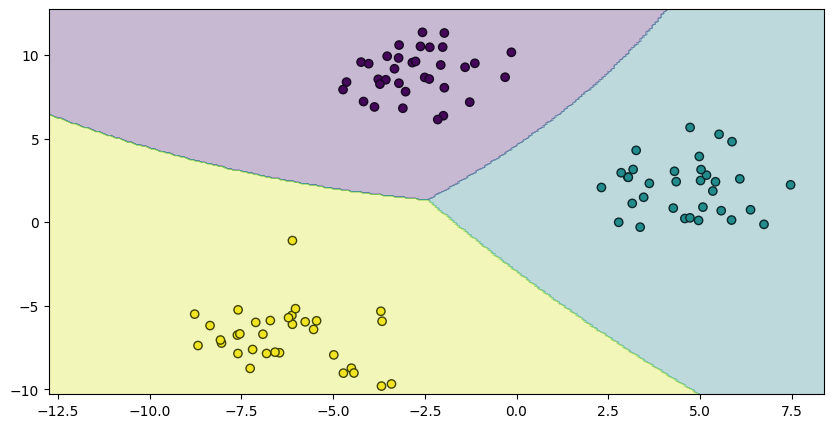

In [ ]:
X, Y = make_blobs(n_samples=150, n_features=2, centers=3, cluster_std=1.5, random_state=42)

x_train, y_train, x_test, y_test = X[:100], Y[:100], X[100:], Y[100:]

model = NaiveBayesClassifier()
model.fit(x_train, y_train)

h = .08
x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.flatten(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.scatter(x_train[:, 0], x_train[:, 1], c=y_train, edgecolors='k')
ax.contourf(xx, yy, Z, alpha=0.3)

In [ ]:
print(model.score(x_test, y_test))

1.0


# Resources

- https://en.wikipedia.org/wiki/Naive_Bayes_classifier
- https://scikit-learn.org/stable/modules/naive_bayes.html